# Module 2: Epidemic Modeling

## Team Members: 
### Sara Elster, Dani Folks

## Project Title: 
### *Modeling the Impact of a Novel Virus on Population Dynamics and Intervention Strategies*

## Project Goal:
### This project seeks to characterize and predict the spread of an unknown virus utilizing exponential growth modeling and SEIR simulation, and to evaluate the effectiveness of various intervention strategies implemented during the outbreak.

## 1. Data and disease background
The outbreak of this unknown virus within the UVA and VT populations demonstrated significant transmission dynamics, with a prevalence of 18.3% of the total UVA population infected and an incidence of 0.83% of the UVA population at the virus' peak transmission (Day 83). The virus is a (+) ssRNA virus measuring 50-80 nm with a ~10 kb genome. It is transmitted through respiratory droplets and exhibits an incubation period of 12-18 days and a symptomatic period of 5-9 days. However, it was determined that individuals are infectious up to 2 days before the start of the symptomatic period. Symptoms of the disease include mild respiratory symptoms, such as sore throat, low-grade fever, and fatigue, as well as rash, gastrointestinal symptoms, and joint pain. Biological mechanisms of the virus likely involve inhalation of viral respiratory droplets when an infected person coughs, entry into host respiratory epithelial cells via endocytosis, hijacking of host cells for production of viral proteins, replication of viral genome, and release to infect more cells. This leads to inflammation in the respiratory tract as well as immune responses. Economically, respiratory viruses can impede community function, especially of a university. Viral epidemics often lead to increased healthcare utilization, lower attendance in class, reduced productivity, and places strain on university health services.

We utilized three datasets with virus cases from days 0-45 (data release 1), days 0-70 (data release 2), and days 0-120 (data release 3). The datasets consisted of three columns each - day, date, and active daily reported cases. The datasets modeled the actual spread of the virus in the UVA and VT populations.

## 2. Data Analysis

### 2a. Methods

First, we estimated initial growth rate (R0) by utilizing the scipy curve_fit function to fit an exponential growth model to our release 1 data (up to day 45) and find the optimal parameters, which we then used to calculate R0. We also plotted the fitted curve to the actual data to determine whether our calculated R0 was a good estimate.

Next, we utilized Euler's method to estimate functions for the SEIR model for our virus. We defined a function that utilized Euler's method to create approximate functions for S, E, I, and R, then used SSE and grid search to find the best values for beta, gamma, and sigma. Finally, using our initial conditions and our optimal values for beta, sigma, and gamma, we used the Euler function to generate models for S, E, I, and R, and we plotted the I function to our actual data from release 2 (up to day 70).

Next, we used the Euler function with our optimal beta, gamma, and sigma values to model S, E, I, and R functions up to day 120. We utilized these functions to predict the peak of the virus. We plotted our model graph against the data from release 3 (up to day 120), and calculated the error in the predicted and actual peak.

Finally, we wanted to model the effects of various intervention strategies on epidemic spread at VT. To do this, we first used the Euler funcion and optimal beta, sigma, and gamma values to determine a baseline model for the VT population with no intervention. Then, we used the same Euler function, but modified the beta, gamma, and/or sigma parameters to represent the effects of different intervention strategies on viral spread/transmission. We plotted these modified functions against the baseline to determine the most effective intervention strategy.



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

First, we imported the libraries necessary for computation and loaded the data from release 1.

In [87]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Load the data
data = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

Next, we used the Scipy curve_fit function to estimate R0 from the data.

In [88]:
# We used the day number and active cases to fit an exponential growth curve to estimate R0
# Defining the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fitting the exponential growth model to the data with scipy curve_fit
x_data = data['day'].values.astype(float)
y_data = data['active reported daily cases'].values.astype(float)
popt, pcov = curve_fit(exponential_growth, x_data, y_data)

r_fit = popt[0]

# Approximate R0
D = 9 # Background said the symptomatic period is 5-9 days, but with 2 days infectious before symptoms appear. We took the average for the infectious period to be 9 days.

r0 = np.exp(r_fit * D)

print("Estimated growth rate R0: ", r0)

Estimated growth rate R0:  2.9832723355682464


Finally, we added the fitted exponential curve to the actual virus data to see whether it was a good estimate.

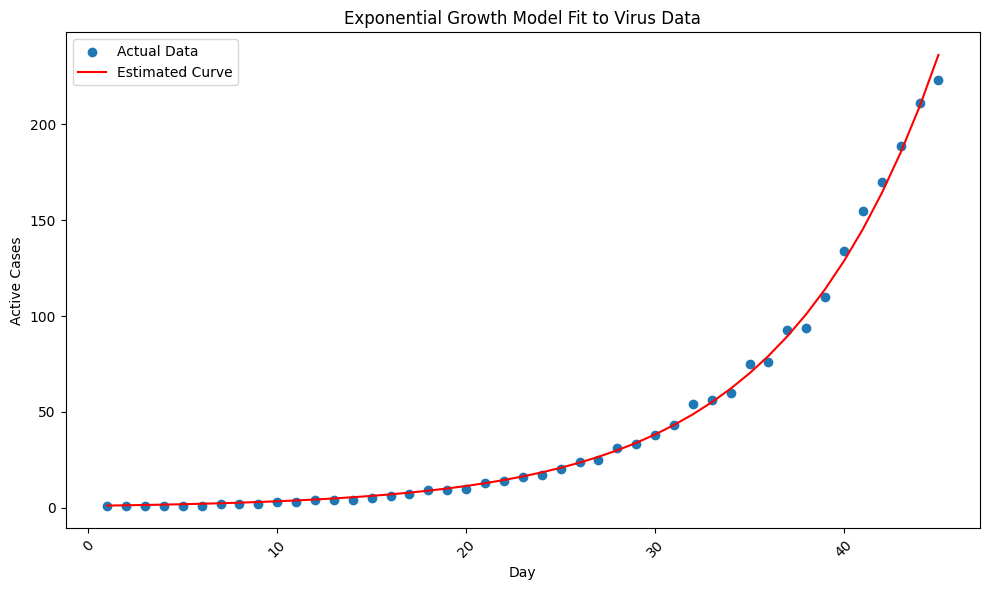

In [89]:
# Add the fit as a line on top of your scatterplot.
# Generate fitted curve
y_fitted = exponential_growth(x_data, r_fit)

# Plot fitted curve and actual data
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label = "Actual Data")
plt.plot(x_data, y_fitted, color = "red", label = "Estimated Curve")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Growth Model Fit to Virus Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show() 

##### Preliminary Analysis/Conclusions:

**Analysis of Data Release 1:**
1. What do you notice about initial infections?

The initial infections seem to be very low, with only a few cases reported in the early days. This could indicate that the virus was not spreading widely at the beginning, or that there was limited testing and reporting.

2. How could we measure how quickly its spreading?

We could measure how quickly the virus is spreading by calculating the growth rate of active cases over time. This can be done by taking the difference in active cases between consecutive days and dividing it by the number of active cases on the previous day to get a percentage growth rate. 

3. What information about the virus would be helpful in determining the shape of the outbreak curve?

Information about the virus's transmission rate, incubation period, and recovery time would be helpful in determining the shape of the outbreak curve.


**Conclusions:**

Our estimated R0 was 2.98. Two viruses with a similar R0 value of 3 are COVID-19 and Meningococcal Disease. COVID-19 is a respiratory virus caused by the coronavirus *SARS-CoV-2*. It spreads through respiratory droplets and aerosols and symptoms range from fever and cough to severe illness infecting the lungs and other organs. The Meningococcal Disease is a bacterial infection caused by *Neisseria meningitidis*. It is spread through close respiratory or throat contact, and can lead to meningitis and bloodstream infections.

Generally, we believe our R0 estimate is accurate. However, because the symptomatic period given was a range of 5-9 days, our value for infectious period (D) may not be completely accurate, which would affect the calculation of R0.

### 2c. Use Euler's method to solve the SEIR model.

First, we imported the necessary libraries.

In [90]:
# SEIR model fitting with Euler's method
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Next, we pulled the dataset from Data Release 2 and organized the days and cases into their own data sets.

In [91]:
# Loading the data
data_2 = pd.read_csv(r"/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)

timepoints = data_2['day'].values.astype(float)
infected_data = data_2['active reported daily cases'].values.astype(float)

Finally, we used Euler's method to approximate S, E, I, and R parameters of SEIR model.

In [92]:
# Initial conditions
N = 17900           # total UVA population
I0 = infected_data[0]
E0 = I0             # reasonable first guess: exposed starts similar to infected
R0_init = 0         # initial recovered is 0
S0 = N - E0 - I0 - R0_init

# Euler method for SEIR
def euler_seir(timepoints, N, S0, E0, I0, R0, beta, sigma, gamma):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for i in range(len(timepoints) - 1):
        dSdt = -beta * S[i] * I[i] / N
        dEdt = beta * S[i] * I[i] / N - sigma * E[i]
        dIdt = sigma * E[i] - gamma * I[i]
        dRdt = gamma * I[i]

        S[i + 1] = S[i] + dSdt * dt
        E[i + 1] = E[i] + dEdt * dt
        I[i + 1] = I[i] + dIdt * dt
        R[i + 1] = R[i] + dRdt * dt

    return S, E, I, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

First, we used SSE to determine the optimal values for beta, sigma, and gamma, and the corresponding SSE.

In [93]:
# SSE calculation
def calculate_sse(model_I, data_I):
    return np.sum((model_I - data_I) ** 2)

# Parameter search
def fit_seir_parameters(timepoints, N, S0, E0, I0, R0, infected_data):
    # These are reasonable starter ranges for a daily-timescale outbreak
    beta_values = np.linspace(0.1, 1.2, 30)
    sigma_values = np.linspace(0.05, 0.6, 25)
    gamma_values = np.linspace(0.05, 0.6, 25)

    best_sse = np.inf
    best_beta = None
    best_sigma = None
    best_gamma = None

    sse_results = []

    for b in beta_values:
        for s in sigma_values:
            for g in gamma_values:
                S, E, I, R = euler_seir(timepoints, N, S0, E0, I0, R0, b, s, g)
                sse = calculate_sse(I, infected_data)
                sse_results.append((b, s, g, sse))

                if sse < best_sse:
                    best_sse = sse
                    best_beta = b
                    best_sigma = s
                    best_gamma = g

    return best_beta, best_sigma, best_gamma, best_sse, sse_results

### 2e. Plot the model-predicted infections over time compared to the data.

Finally, we ran the calculations and plotted the corresponding best fit model with the actual data.

Best beta = 0.3275862068965517
Best sigma = 0.5770833333333334
Best gamma = 0.14166666666666666
Best SSE = 74115.92618245789


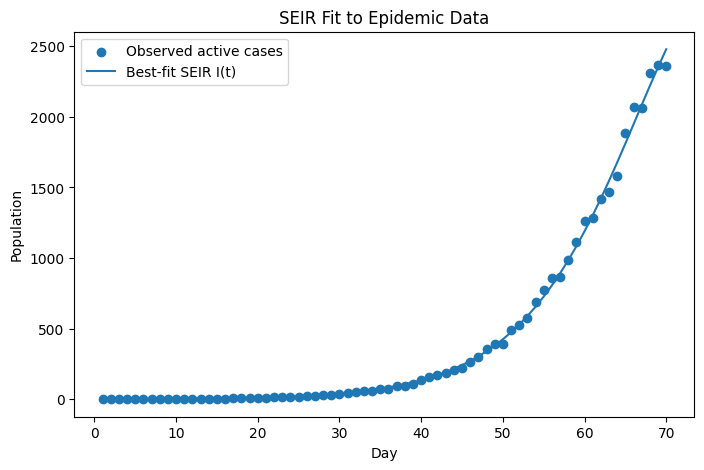

In [94]:
# Fit the model
best_beta, best_sigma, best_gamma, best_sse, sse_results = fit_seir_parameters(
    timepoints, N, S0, E0, I0, R0_init, infected_data
)

print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Best SSE =", best_sse)

# Run best-fit model on observed time window
S_fit, E_fit, I_fit, R_fit = euler_seir(
    timepoints, N, S0, E0, I0, R0_init,
    best_beta, best_sigma, best_gamma
)

# Plot model fit vs data
plt.figure(figsize=(8, 5))
plt.scatter(timepoints, infected_data, label='Observed active cases')
plt.plot(timepoints, I_fit, label='Best-fit SEIR I(t)')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Fit to Epidemic Data')
plt.legend()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.

To predict the peak and plot the predicted graph, we calculated future timepoints until day 200 using the approximated S, E, I, and R values. Then, we used these values to predict what the peak number of cases would be and the corresponding day.

In [95]:
# Predict the future peak
future_days = 120
future_timepoints = np.arange(timepoints[0], timepoints[0] + future_days + 1, 1)

S_future, E_future, I_future, R_future = euler_seir(
    future_timepoints, N, S0, E0, I0, R0_init,
    best_beta, best_sigma, best_gamma
)

peak_index = np.argmax(I_future)
peak_day = future_timepoints[peak_index]
peak_value = I_future[peak_index]

print("Predicted peak infected population =", peak_value)
print("Predicted peak day =", peak_day)


Predicted peak infected population = 3035.236821284492
Predicted peak day = 78.0


Finally, we used the predicted data to plot the predicted graph of number of cases vs days as well as the peak number of cases and days.

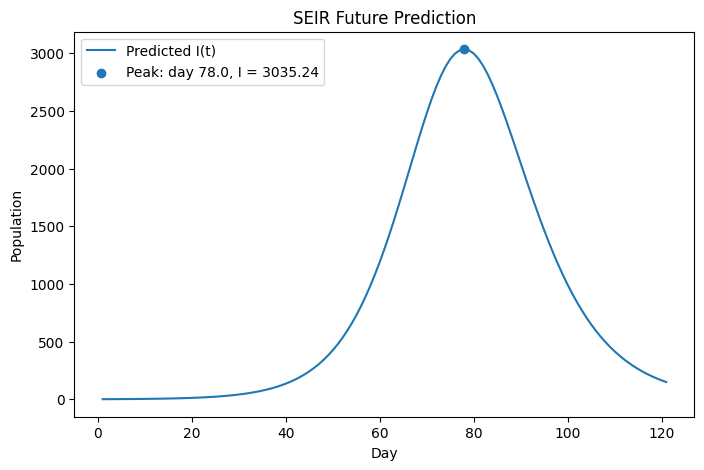

In [96]:
# Plot future prediction
plt.figure(figsize=(8, 5))
plt.plot(future_timepoints, I_future, label='Predicted I(t)')
plt.scatter(peak_day, peak_value, label=f'Peak: day {peak_day}, I = {peak_value:.2f}')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Future Prediction')
plt.legend()
plt.show()

### 2f. Plot the full dataset (Data Release #3) against your model.

First, we loaded the actual data from data release 3.


In [97]:
# Loading data from data release 3
data_3 = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)

x_data_actual = data_3['day'].values.astype(float)
y_data_actual = data_3['active reported daily cases'].values.astype(float)

Once the data was loaded, we were able to plot the actual data with the predicted curve.

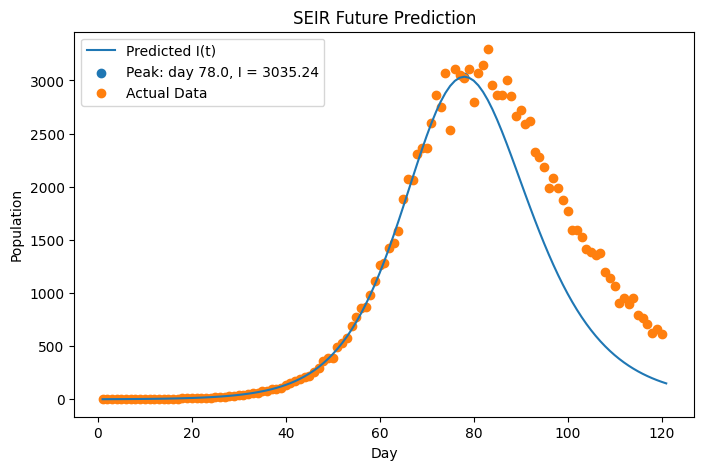

In [98]:
# Plotting full dataset against SEIR model
plt.figure(figsize=(8, 5))
plt.plot(future_timepoints, I_future, label='Predicted I(t)')
plt.scatter(peak_day, peak_value, label=f'Peak: day {peak_day}, I = {peak_value:.2f}')
plt.scatter(x_data_actual, y_data_actual, label = "Actual Data")
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Future Prediction')
plt.legend()
plt.show()

Finally, we calculated both the true and relative error for both the predicted peak number of cases and peak day of infection. To do this, we iterated through data set 3 to find the actual peak number of cases and corresponding day, then calculated the true and relative errors based off of these numbers.

In [99]:
# Estimating error

# Finding actual peak value and day from data release 3
actual_peak_value = 0
actual_peak_day = 0
for num in range(len(y_data_actual)):
    if y_data_actual[num] > actual_peak_value:
        actual_peak_value = y_data_actual[num]
        actual_peak_day = x_data_actual[num]
print("Actual peak number of cases", actual_peak_value)
print("Actual peak day:", actual_peak_day)

# Calculating true error for value and day
true_error_value = actual_peak_value - peak_value
true_error_day = actual_peak_day - peak_day
print("True error for peak number of cases:", round(true_error_value, 2))
print("True error value for peak day:", true_error_day)

# Calculating percent error
rel_error_value = (true_error_value/actual_peak_value)*100
rel_error_day = (true_error_day/actual_peak_day)*100
print("Relative (%) error for peak number if cases: " + str(round(rel_error_value, 2)) + "%")
print("Relative (%) error for peak day: " + str(round(rel_error_day, 2)) + "%")

Actual peak number of cases 3294.0
Actual peak day: 83.0
True error for peak number of cases: 258.76
True error value for peak day: 5.0
Relative (%) error for peak number if cases: 7.86%
Relative (%) error for peak day: 6.02%


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)

The intervention strategies we modeled were masking mandates, vaccine campaign, vaccine rollout, testing/quarantine starting at day 70, and closing school for two weeks.

First, we imported necessary packages and loaded release 3 data.



In [100]:
# Importing necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading data from data release 3
data_3 = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)
x_data_actual = data_3['day'].values.astype(float)
y_data_actual = data_3['active reported daily cases'].values.astype(float)

Next, we utilized the best beta, sigma, and gamma values calculated from the SSE grid search method.

In [101]:
# Best values for beta, sigma, and gamma from Euler calculation
best_beta = 0.3275862068965517
best_sigma = 0.5770833333333334
best_gamma = 0.14166666666666666

Next, we used the Euler function to model the spread of the virus at VT from Day 0-70.

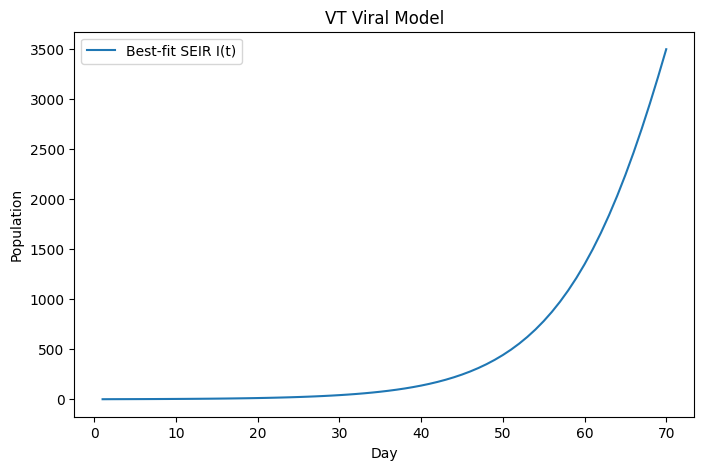

In [102]:
# VT Infection Day 0-70
def euler_seir(timepoints, N, S0, E0, I0, R0, beta, sigma, gamma):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for i in range(len(timepoints) - 1):
        dSdt = -beta * S[i] * I[i] / N
        dEdt = beta * S[i] * I[i] / N - sigma * E[i]
        dIdt = sigma * E[i] - gamma * I[i]
        dRdt = gamma * I[i]

        S[i + 1] = S[i] + dSdt * dt
        E[i + 1] = E[i] + dEdt * dt
        I[i + 1] = I[i] + dIdt * dt
        R[i + 1] = R[i] + dRdt * dt

    return S, E, I, R


S0 = 38857 # VT student population
E0 = 1
I0 = 1
R0 = 0
timepoints = range(1,71)
N = int(S0) + int(E0) + int(I0) + int(R0)

S_fit, E_fit, I_fit, R_fit = euler_seir(
    timepoints, N, S0, E0, I0, R0,
    best_beta, best_sigma, best_gamma
)

plt.figure(figsize=(8, 5))
plt.plot(timepoints, I_fit, label='Best-fit SEIR I(t)')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('VT Viral Model')
plt.legend()
plt.show()

Next, we set the baseline for the full VT epidemic model (Days 0-120) without intervention, and we defined the number of cases at day 70, which would be the starting point of all of our intervention strategies. 

In [103]:
# Baseline Day 0-120
timepoints_full = np.arange(1, 121)
S_base, E_base, I_base, R_base = euler_seir(
    timepoints_full, N, S0, E0, I0, R0,
    best_beta, best_sigma, best_gamma
)

# day 70 state
day70_index = np.where(timepoints_full == 70)[0][0]
S70 = S_base[day70_index]
E70 = E_base[day70_index]
I70 = I_base[day70_index]
R70 = R_base[day70_index]

# post-70 timepoints
timepoints_post70 = np.arange(70, 121)

# post-70 baseline
S_post_base, E_post_base, I_post_base, R_post_base = euler_seir(
    timepoints_post70, N, S70, E70, I70, R70,
    best_beta, best_sigma, best_gamma
)

# interventions
S_mask, E_mask, I_mask, R_mask = euler_seir(
    timepoints_post70, N, S70, E70, I70, R70,
    best_beta, best_sigma, best_gamma
)

Next, we created SEIR models for all of our intervention methods by altering beta, gamma, and/or sigma to model the effect of the method.

In [104]:
# Intervention 1: Masking mandate
# reduces transmission by 40%
beta_mask = 0.6 * best_beta

S_mask, E_mask, I_mask, R_mask = euler_seir(
    timepoints_post70, N, S70, E70, I70, R70,
    beta_mask, best_sigma, best_gamma
)

# Intervention 2: Vaccine campaign
# single event on day 70
# vaccinate 2000 students with 90% efficacy
# move 1800 from S to R
effective_vax_campaign = 2000 * 0.90

S70_vax_campaign = max(S70 - effective_vax_campaign, 0)
R70_vax_campaign = R70 + min(effective_vax_campaign, S70)

S_vax_campaign, E_vax_campaign, I_vax_campaign, R_vax_campaign = euler_seir(
    timepoints_post70, N, S70_vax_campaign, E70, I70, R70_vax_campaign,
    best_beta, best_sigma, best_gamma
)

# Intervention 3: Vaccine rollout
# vaccinate 1000 students on day 70, 80, 90 with 90% efficacy
# move 900 from S to R at each event
def euler_seir_vaccine_rollout(timepoints, N, S0, E0, I0, R0, beta, sigma, gamma, vax_days, vax_amount, efficacy):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    effective_vax = vax_amount * efficacy

    for i in range(len(timepoints) - 1):
        current_day = timepoints[i]

        # apply vaccination at the start of specified days
        if current_day in vax_days:
            moved = min(effective_vax, S[i])
            S[i] -= moved
            R[i] += moved

        dSdt = -beta * S[i] * I[i] / N
        dEdt = beta * S[i] * I[i] / N - sigma * E[i]
        dIdt = sigma * E[i] - gamma * I[i]
        dRdt = gamma * I[i]

        S[i + 1] = S[i] + dSdt * dt
        E[i + 1] = E[i] + dEdt * dt
        I[i + 1] = I[i] + dIdt * dt
        R[i + 1] = R[i] + dRdt * dt

    return S, E, I, R

S_vax_rollout, E_vax_rollout, I_vax_rollout, R_vax_rollout = euler_seir_vaccine_rollout(
    timepoints_post70, N, S70, E70, I70, R70,
    best_beta, best_sigma, best_gamma,
    vax_days=[70, 80, 90],
    vax_amount=1000,
    efficacy=0.90
)

# Intervention 4: Testing + quarantine
# reduces infectious period by 2 days
# infectious period = 1/gamma
# new gamma = 1/(old infectious period - 2)
infectious_period = 1 / best_gamma
new_infectious_period = infectious_period - 2

if new_infectious_period <= 0:
    raise ValueError("New infectious period is not valid. Check gamma.")

gamma_test = 1 / new_infectious_period

S_test, E_test, I_test, R_test = euler_seir(
    timepoints_post70, N, S70, E70, I70, R70,
    best_beta, best_sigma, gamma_test
)

# Intervention 5: 2-week school closure
# day 70-84: only 20% of normal contacts
# after closure: return to normal
def euler_seir_school_closure(timepoints, N, S0, E0, I0, R0,
                              beta_normal, sigma, gamma,
                              closure_start, closure_end, closure_contact_fraction):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for i in range(len(timepoints) - 1):
        current_day = timepoints[i]

        if closure_start <= current_day < closure_end:
            beta_current = beta_normal * closure_contact_fraction
        else:
            beta_current = beta_normal

        dSdt = -beta_current * S[i] * I[i] / N
        dEdt = beta_current * S[i] * I[i] / N - sigma * E[i]
        dIdt = sigma * E[i] - gamma * I[i]
        dRdt = gamma * I[i]

        S[i + 1] = S[i] + dSdt * dt
        E[i + 1] = E[i] + dEdt * dt
        I[i + 1] = I[i] + dIdt * dt
        R[i + 1] = R[i] + dRdt * dt

    return S, E, I, R

S_close, E_close, I_close, R_close = euler_seir_school_closure(
    timepoints_post70, N, S70, E70, I70, R70,
    best_beta, best_sigma, best_gamma,
    closure_start=70,
    closure_end=84,
    closure_contact_fraction=0.20
)

Next, we plotted all of our intervention models against the baseline.

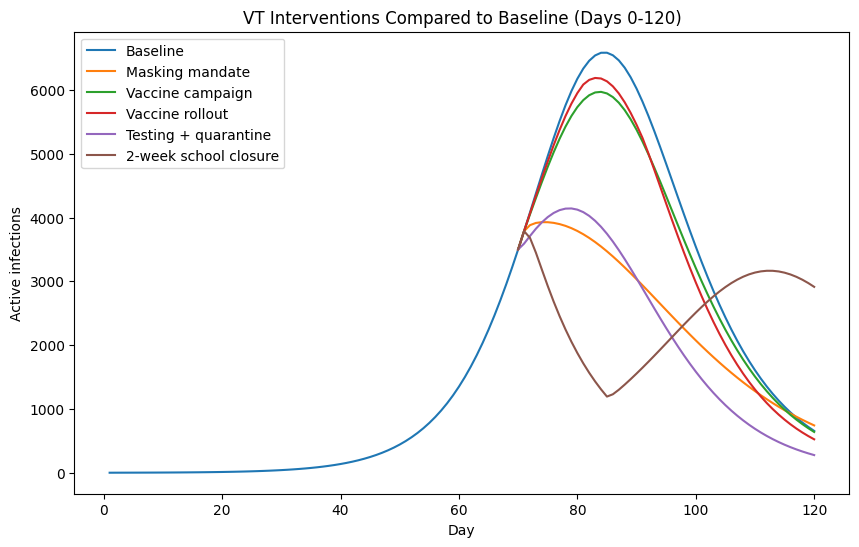

In [105]:
# Plot all interventions vs baseline
plt.figure(figsize=(10, 6))
plt.plot(timepoints_full, I_base, label='Baseline')
plt.plot(timepoints_post70, I_mask, label='Masking mandate')
plt.plot(timepoints_post70, I_vax_campaign, label='Vaccine campaign')
plt.plot(timepoints_post70, I_vax_rollout, label='Vaccine rollout')
plt.plot(timepoints_post70, I_test, label='Testing + quarantine')
plt.plot(timepoints_post70, I_close, label='2-week school closure')

plt.xlabel('Day')
plt.ylabel('Active infections')
plt.title('VT Interventions Compared to Baseline (Days 0-120)')
plt.legend()
plt.show()

Finally, we calculated the peak reduction and total cases prevented for each intervention method compared to the baseline.

In [106]:
# Peak infections and total cases prevented from day 70-120
def intervention_metrics(name, S_int, I_int, S_base, I_base):
    peak_base = np.max(I_base)
    peak_int = np.max(I_int)

    total_cases_base = S_base[0] - S_base[-1]
    total_cases_int = S_int[0] - S_int[-1]

    peak_reduction = peak_base - peak_int
    cases_prevented = total_cases_base - total_cases_int

    print(f'--- {name} ---')
    print(f'Peak infections (baseline): {peak_base:.2f}')
    print(f'Peak infections (intervention): {peak_int:.2f}')
    print(f'Peak reduction: {peak_reduction:.2f}')
    print(f'Total cases day 70-120 (baseline): {total_cases_base:.2f}')
    print(f'Total cases day 70-120 (intervention): {total_cases_int:.2f}')
    print(f'Cases prevented: {cases_prevented:.2f}')
    print()

intervention_metrics('Masking mandate', S_mask, I_mask, S_post_base, I_post_base)
intervention_metrics('Vaccine campaign', S_vax_campaign, I_vax_campaign, S_post_base, I_post_base)
intervention_metrics('Vaccine rollout', S_vax_rollout, I_vax_rollout, S_post_base, I_post_base)
intervention_metrics('Testing + quarantine', S_test, I_test, S_post_base, I_post_base)
intervention_metrics('2-week school closure', S_close, I_close, S_post_base, I_post_base)

--- Masking mandate ---
Peak infections (baseline): 6583.49
Peak infections (intervention): 3927.81
Peak reduction: 2655.69
Total cases day 70-120 (baseline): 23988.63
Total cases day 70-120 (intervention): 13915.77
Cases prevented: 10072.86

--- Vaccine campaign ---
Peak infections (baseline): 6583.49
Peak infections (intervention): 5969.97
Peak reduction: 613.52
Total cases day 70-120 (baseline): 23988.63
Total cases day 70-120 (intervention): 21792.54
Cases prevented: 2196.09

--- Vaccine rollout ---
Peak infections (baseline): 6583.49
Peak infections (intervention): 6188.02
Peak reduction: 395.48
Total cases day 70-120 (baseline): 23988.63
Total cases day 70-120 (intervention): 23167.72
Cases prevented: 820.91

--- Testing + quarantine ---
Peak infections (baseline): 6583.49
Peak infections (intervention): 4142.81
Peak reduction: 2440.69
Total cases day 70-120 (baseline): 23988.63
Total cases day 70-120 (intervention): 18429.92
Cases prevented: 5558.71

--- 2-week school closure --

## Verify and validate your analysis: 

To verify and validate our analysis, we followed a multi-step approach that combined parameter estimation, model fitting, and comparison to real data. First, we estimated the initial growth rate R0 by using the scipy.optimize.curve_fit function to fit an exponential growth model to the early outbreak data (release 1, up to day 45). We compared the fitted curve to the actual data to confirm that the estimated growth rate reasonably captured the early exponential phase. Next, we implemented an SEIR model using Euler’s method by defining a function that iteratively approximates the S,E,I, and R compartments. We then performed a grid search using the sum of squared errors (SSE) to determine the optimal values of beta, sigma, and gamma that best fit the observed data (release 2, up to day 70). We validated this fit by plotting the model’s infectious population I(t) against the real data and confirming that it captured the trend in cases. Using these optimized parameters and initial conditions, we extended the model to day 120 and compared the predicted epidemic curve to the full dataset (release 3), including evaluating the accuracy of the predicted peak. Finally, we modeled intervention strategies by first establishing a no-intervention baseline using the Euler SEIR function and then modifying parameters such as beta and gamma to represent masking, vaccination, testing, and closure scenarios. We verified that each intervention was applied correctly at day 70 and validated the results by comparing peak infections and total cases prevented relative to the baseline, ensuring that the outcomes were both mathematically consistent and epidemiologically reasonable.


Based on the parameters estimated in the SEIR code and the modeled disease characteristics, the outbreak is most consistent with mumps. The model assumes respiratory droplet transmission, an incubation period of approximately 12–18 days, and an infectious period beginning about 2 days before symptom onset with a symptomatic duration of 5–9 days—all of which align closely with established epidemiology of mumps. For example, the CDC reports that mumps has an incubation period typically 16–18 days (range 12–25 days) and that individuals are infectious from about 2 days before to 5 days after symptom onset, with transmission occurring through respiratory droplets and saliva . These features match the assumptions embedded in the fitted SEIR parameters and the resulting epidemic dynamics, supporting the conclusion that the simulated pathogen is mumps. https://www.cdc.gov/mumps/communication-resources/mumps-clinical-diagnosis.html

## Conclusions and Ethical Implications: 
Overall, this project demonstrates how mathematical modeling can be used to understand and predict the spread of infectious disease in a real population. By first estimating the initial growth rate from early outbreak data and then fitting an SEIR model using Euler’s method and grid search, we were able to generate a model that reasonably captured the full epidemic curve, including the rise, peak, and decline in cases. This highlights the importance of fitting models to the appropriate portion of data—using only early exponential growth led to unrealistic projections, while incorporating the full dataset produced more accurate and biologically meaningful results. Using the fitted model, we then evaluated multiple intervention strategies and found that reducing transmission (masking), increasing immunity (vaccination), and shortening the infectious period (testing and quarantine) can all significantly reduce peak infections and total cases. Among these, masking and vaccination emerged as the most effective and practical strategies, particularly when used together.

From an ethical standpoint, this project emphasizes the responsibility of using models carefully and transparently, as inaccurate assumptions or poorly fit parameters can lead to misleading conclusions that may affect real-world decisions. It also highlights the trade-offs between public health interventions and individual or societal impacts. While strategies like masking and vaccination are effective and relatively low-cost, they still require public trust, accessibility, and compliance. More restrictive measures, such as school closures, may reduce transmission but can have significant negative effects on education, mental health, and equity. Therefore, ethical decision-making should prioritize interventions that are both effective and equitable, minimizing harm while maximizing public health benefits. Ultimately, this project underscores the value of data-driven decision making in public health, while also recognizing the importance of balancing scientific insight with ethical considerations.


## Limitations and Future Work: 
While our SEIR modeling approach provides useful insight into the spread of disease and the impact of interventions at VT, several limitations should be considered. First, the model assumes a homogeneously mixed population, meaning every individual has an equal chance of interacting with others. In reality, contact patterns on a college campus are highly structured (e.g., dorms, classrooms, social groups), which can significantly affect transmission dynamics. Second, key parameters were assumed to be constant over time, even though real-world behavior, policy changes, and awareness can alter transmission rates throughout an outbreak. Third, the model does not explicitly account for asymptomatic cases, underreporting, or behavioral compliance, which could lead to discrepancies between modeled infections and observed reported cases. Additionally, our parameter fitting relied on minimizing SSE, which may not fully capture uncertainty or variability in the data, and small errors early in the model can propagate into larger differences in long-term predictions.

There are also limitations in how interventions were modeled. Each intervention was applied as a simple change to a parameter which does not fully capture real-world complexities such as delayed implementation, partial compliance, or logistical constraints. For example, vaccination was modeled as an immediate transfer from susceptible to recovered, without considering rollout delays, varying efficacy across individuals, or waning immunity. Similarly, testing and quarantine effectiveness depends heavily on participation and timeliness, which were simplified in our model.

Future work could improve this analysis by incorporating more realistic features, such as time-varying parameters, network-based or stratified models (e.g., separating students by housing or class schedules), and stochastic elements to account for randomness in transmission. Including compartments for asymptomatic or partially immune individuals would also improve biological realism. Additionally, using more advanced parameter estimation techniques (such as optimization algorithms or Bayesian inference) could better quantify uncertainty in the model. Finally, future analyses could explore combined intervention strategies in greater depth and evaluate cost-benefit trade-offs to better inform real-world decision making.